In [3]:
import os
import shutil

os.makedirs("images", exist_ok=True)

source_folder = r"C:\Users\salon\OneDrive\Desktop\Data_Science\Deep Learning\Deep fashion - 15-aug- working for deploy\images"

for file in os.listdir(source_folder):
    if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
        shutil.copy(
            os.path.join(source_folder, file),
            "images"
        )

print("Images copied successfully!")

SameFileError: 'C:\\Users\\salon\\OneDrive\\Desktop\\Data_Science\\Deep Learning\\Deep fashion - 15-aug- working for deploy\\images\\anarkali suit with a long, olive green kurta adorned with intricate embroidery around the neckline and cuffs, paired with matching fitted trousers.jpg' and 'images\\anarkali suit with a long, olive green kurta adorned with intricate embroidery around the neckline and cuffs, paired with matching fitted trousers.jpg' are the same file

In [10]:
import os

image_directory = "images"

image_paths_list = []

for file in os.listdir(image_directory):

    if file.lower().endswith(
        (".jpg", ".jpeg", ".png", ".webp")
    ):

        full_path = os.path.join(
            image_directory,
            file
        )

        if os.path.isfile(full_path):
            image_paths_list.append(full_path)

print("Total valid images:", len(image_paths_list))

Total valid images: 95


In [11]:
missing_files = [
    path for path in image_paths_list
    if not os.path.exists(path)
]

print("Missing files:", len(missing_files))

Missing files: 0


In [9]:
for file in os.listdir("images"):
    if "turquoise" in file.lower():
        print(repr(file))

'anarkali suit. It consists of a turquoise skirt with detailed golden embroidery, a multicolored blouse with floral patterns, and an orange dupatta with lace borders.jpg'


In [ ]:
import os
import numpy as np

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model


# Create VGG16 feature extractor
base_model = VGG16(
    weights="imagenet",
    include_top=False
)

model = Model(
    inputs=base_model.input,
    outputs=base_model.output
)


def preprocess_image(img_path):

    img = image.load_img(
        img_path,
        target_size=(224, 224)
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    return preprocess_input(img_array)


def extract_features(model, preprocessed_img):

    features = model.predict(
        preprocessed_img,
        verbose=0
    )

    features = features.flatten()

    norm = np.linalg.norm(features)

    if norm == 0:
        return features

    return features / norm

valid_image_paths = []

for path in image_paths_list:

    if os.path.exists(path):
        valid_image_paths.append(path)
    else:
        print("Missing:", path)

image_paths_list = valid_image_paths

print("Valid images:", len(image_paths_list))

all_features = []
all_image_names = []

for img_path in image_paths_list:

    preprocessed_img = preprocess_image(img_path)

    features = extract_features(
        model,
        preprocessed_img
    )

    all_features.append(features)
    all_image_names.append(img_path)

print("Total images:", len(all_image_names))
print("Feature length:", len(all_features[0]))

58889256/58889256 [==============================] - 5s 0us/step


FileNotFoundError: [Errno 2] No such file or directory: 'images\\anarkali suit. It consists of a turquoise skirt with detailed golden embroidery, a multicolored blouse with floral patterns, and an orange dupatta with lace borders.jpg'

In [34]:
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt
from PIL import Image

def recommend_fashion_items_cnn(input_image_path, all_features, all_image_names, model, top_n=5):
    preprocessed_img = preprocess_image(input_image_path)
    input_features = extract_features(model, preprocessed_img)

    similarities = [1 - cosine(input_features, other_feature) for other_feature in all_features]

    # sort in descending order (most similar first)
    similar_indices = np.argsort(similarities)[::-1]

    # remove input image + take top_n
    similar_indices = [
        idx for idx in similar_indices
        if all_image_names[idx] != input_image_path
    ][:top_n]

    plt.figure(figsize=(15, 10))

    # input image
    plt.subplot(1, top_n + 1, 1)
    plt.imshow(Image.open(input_image_path))
    plt.title("Input Image")
    plt.axis('off')

    # recommendations
    for i, idx in enumerate(similar_indices, start=1):
        plt.subplot(1, top_n + 1, i + 1)
        plt.imshow(Image.open(all_image_names[idx]))
        plt.title(f"Recommendation {i}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
#save model
model.save("vgg16_feature_extractor.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


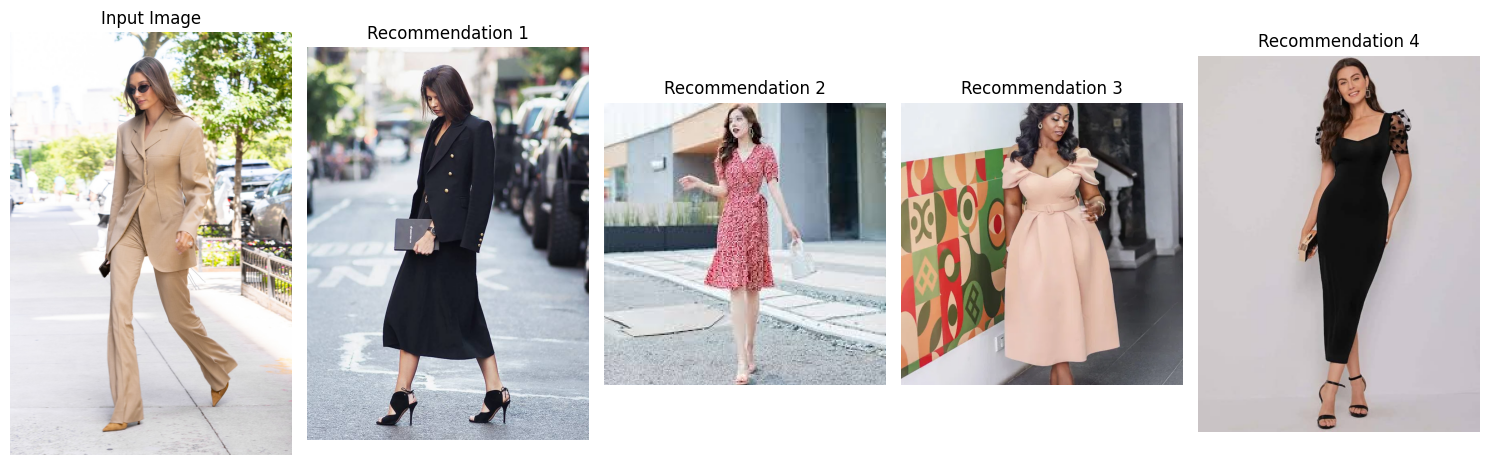

In [36]:
input_image_path = 'images/well-fitted beige suit.jpg'
recommend_fashion_items_cnn(input_image_path, all_features, all_image_names, model, top_n=4)

In [ ]:
import pickle

with open("features.pkl", "wb") as f:
    pickle.dump(all_features, f)

with open("filenames.pkl", "wb") as f:
    pickle.dump(all_image_names, f)